In [1]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [3]:
# Check files uploaded
import os
os.listdir()

['.config', 'fear_greed_index.csv', 'historical_data.csv', 'sample_data']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [5]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [6]:
print(sentiment.info())
print(trades.info())

print(sentiment.isnull().sum())
print(trades.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [8]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [26]:
# Clean column names
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

# Convert to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')

# Drop invalid rows
sentiment = sentiment.dropna(subset=['date'])
trades = trades.dropna(subset=['Timestamp'])

# Sort data (VERY IMPORTANT for merge_asof)
sentiment = sentiment.sort_values('date')
trades = trades.sort_values('Timestamp')

# Merge using nearest timestamp
merged = pd.merge_asof(
    trades,
    sentiment,
    left_on='Timestamp',
    right_on='date',
    direction='nearest'
)

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date_x,timestamp,value,classification,date_y
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,...,173271100,True,0.000000,0.000000e+00,1970-01-01 00:28:00,1970-01-01,1517463000,30,Fear,2018-02-01
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,...,173271100,True,0.000000,0.000000e+00,1970-01-01 00:28:00,1970-01-01,1517463000,30,Fear,2018-02-01
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,...,173271100,True,0.000000,0.000000e+00,1970-01-01 00:28:00,1970-01-01,1517463000,30,Fear,2018-02-01
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2298.40,21.7523,49995.49,BUY,30-12-2023 05:35,-21.7523,Close Short,-264.507968,...,5772555431,True,12.498871,2.850000e+14,1970-01-01 00:28:20,1970-01-01,1517463000,30,Fear,2018-02-01
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,LINK,14.94,749.3000,11194.54,SELL,01-01-2024 09:10,749.3000,Close Long,-87.728044,...,5891710461,True,2.798635,2.080000e+14,1970-01-01 00:28:20,1970-01-01,1517463000,30,Fear,2018-02-01


In [22]:
print(merged.shape)

(0, 20)


In [27]:
print(merged['classification'].value_counts())

classification
Fear    211224
Name: count, dtype: int64


In [28]:
# Convert again cleanly
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
trades['date'] = pd.to_datetime(trades['Timestamp']).dt.date

In [29]:
print("Sentiment unique dates:", len(sentiment['date'].unique()))
print("Trades unique dates:", len(trades['date'].unique()))

# Check common dates
common_dates = set(trades['date']).intersection(set(sentiment['date']))
print("Common Dates:", len(common_dates))

Sentiment unique dates: 2644
Trades unique dates: 1
Common Dates: 0


In [30]:
print(trades[['Timestamp', 'Timestamp IST']].head(10))

                Timestamp     Timestamp IST
83771 1970-01-01 00:28:00  01-05-2023 01:06
83770 1970-01-01 00:28:00  01-05-2023 01:06
83769 1970-01-01 00:28:00  01-05-2023 01:06
39389 1970-01-01 00:28:20  30-12-2023 05:35
39413 1970-01-01 00:28:20  01-01-2024 09:10
39415 1970-01-01 00:28:20  02-01-2024 01:00
39441 1970-01-01 00:28:20  03-01-2024 02:00
39429 1970-01-01 00:28:20  02-01-2024 21:01
39440 1970-01-01 00:28:20  03-01-2024 00:39
39439 1970-01-01 00:28:20  03-01-2024 00:39


In [31]:
# Convert correct column (VERY IMPORTANT)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce', dayfirst=True)

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date

# Check
print("Trades unique dates:", len(trades['date'].unique()))

Trades unique dates: 480


In [32]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [34]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)
print(merged['classification'].value_counts())
print("\nSentiment Distribution:\n", merged['classification'].value_counts())

Merged Shape: (211224, 18)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Sentiment Distribution:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


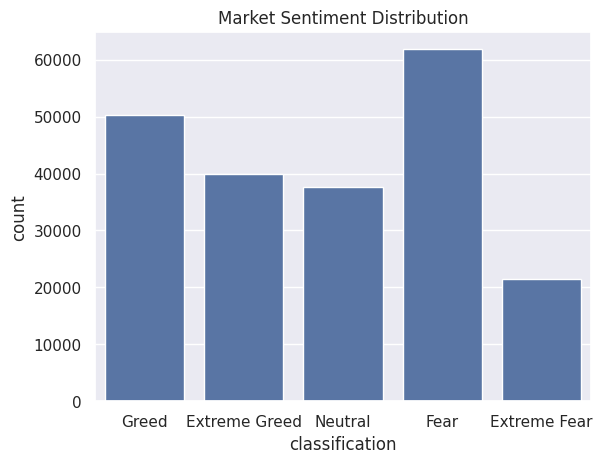

In [35]:
plt.figure()
sns.countplot(x='classification', data=merged)
plt.title("Market Sentiment Distribution")
plt.show()

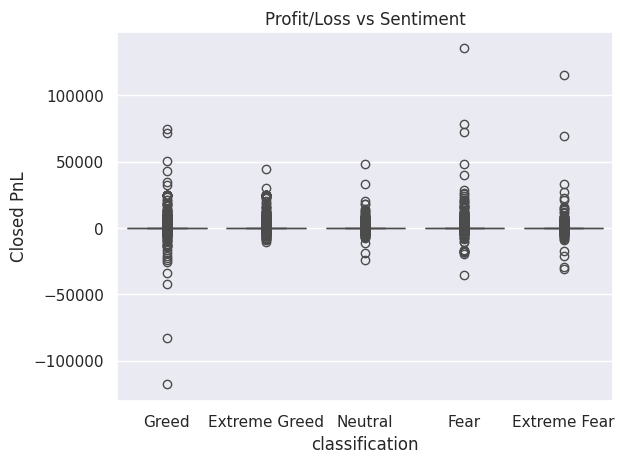

In [36]:
plt.figure()
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Profit/Loss vs Sentiment")
plt.show()

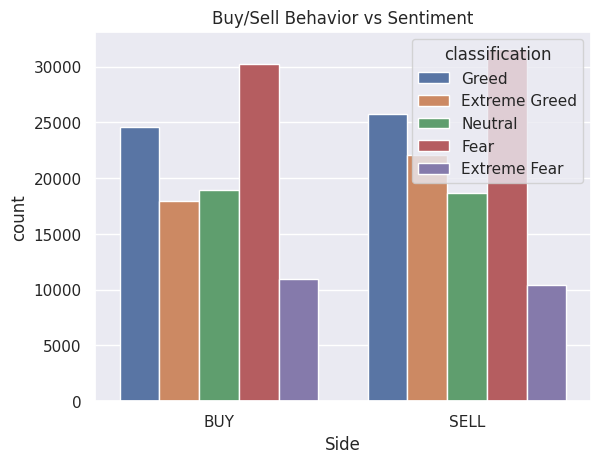

In [37]:
plt.figure()
sns.countplot(x='Side', hue='classification', data=merged)
plt.title("Buy/Sell Behavior vs Sentiment")
plt.show()

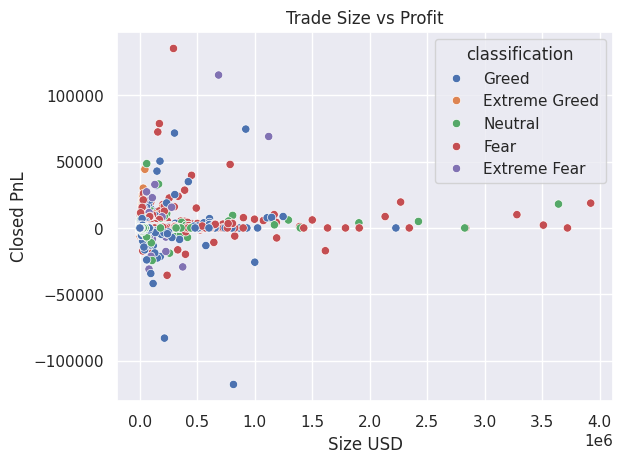

In [38]:
plt.figure()
sns.scatterplot(x='Size USD', y='Closed PnL', hue='classification', data=merged)
plt.title("Trade Size vs Profit")
plt.show()

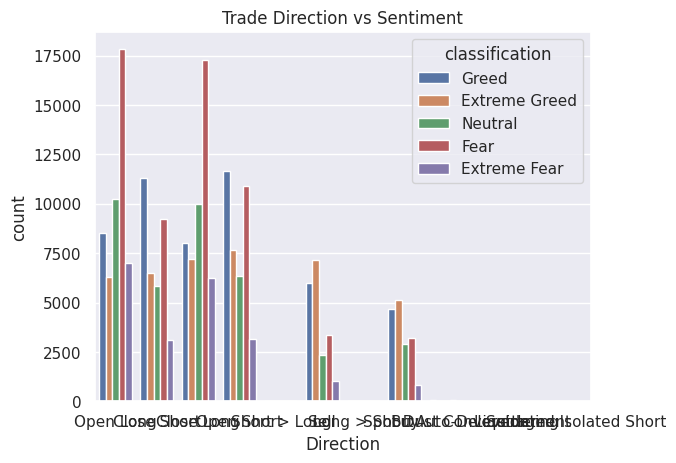

In [39]:
plt.figure()
sns.countplot(x='Direction', hue='classification', data=merged)
plt.title("Trade Direction vs Sentiment")
plt.show()

In [40]:
top_traders = merged.groupby('Account')['Closed PnL'].sum() \
                   .sort_values(ascending=False).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [41]:
print("\nAverage PnL by Sentiment:")
print(merged.groupby('classification')['Closed PnL'].mean())

print("\nTrade Count:")
print(merged['classification'].value_counts())


Average PnL by Sentiment:
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Trade Count:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64
